# Customer Segmentation Analysis for E-commerce

This notebook aims to perform customer segmentation analysis for an e-commerce company by analyzing customer behavior and purchase patterns. The goal is to group customers into distinct segments to inform targeted marketing strategies and improve customer satisfaction.

In [20]:
import pandas as pd

# Load the dataset from the /content/sample_data/ directory
# The file 'ifood_df.csv' is found in the Colab environment's sample_data.
data = pd.read_csv('/content/sample_data/ifood_df.csv')

print("Dataset 'ifood_df.csv' loaded successfully from /content/sample_data/!")
# Display the first 5 rows of the dataset
display(data.head())

Dataset 'ifood_df.csv' loaded successfully from /content/sample_data/!


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [21]:
# Display general information about the dataset
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

None

## Data Cleaning and Preprocessing

In [22]:
# Check for duplicate rows
duplicate_rows = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    data.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")

Number of duplicate rows: 184
Duplicate rows removed.


In [23]:
# Inspect the 'Income' column for non-positive values
non_positive_income = data[data['Income'] <= 0]
print(f"Number of rows with non-positive income: {len(non_positive_income)}")

# Display statistics for the 'Income' column
display(data['Income'].describe())

Number of rows with non-positive income: 0


,Income
count,2021.000000
mean,51687.258783
std,20713.046401
min,1730.000000
25%,35416.000000
50%,51412.000000
75%,68274.000000
max,113734.000000


From the `data.info()` output, we can see that all columns have 2205 non-null entries, which matches the total number of rows. This means there are no missing values in this dataset. However, we should still check for columns with only one unique value, as these would not contribute to the analysis.

In [24]:
# Identify and drop columns with only one unique value (constant columns)
constant_columns = [col for col in data.columns if data[col].nunique() == 1]
print(f"Constant columns: {constant_columns}")

if constant_columns:
    data.drop(columns=constant_columns, inplace=True)
    print(f"Dropped constant columns: {constant_columns}")
else:
    print("No constant columns found.")

# Display general information about the dataset after dropping constant columns
display(data.info())

Constant columns: ['Z_CostContact', 'Z_Revenue']
Dropped constant columns: ['Z_CostContact', 'Z_Revenue']
<class 'pandas.core.frame.DataFrame'>
Index: 2021 entries, 0 to 2204
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2021 non-null   float64
 1   Kidhome               2021 non-null   int64  
 2   Teenhome              2021 non-null   int64  
 3   Recency               2021 non-null   int64  
 4   MntWines              2021 non-null   int64  
 5   MntFruits             2021 non-null   int64  
 6   MntMeatProducts       2021 non-null   int64  
 7   MntFishProducts       2021 non-null   int64  
 8   MntSweetProducts      2021 non-null   int64  
 9   MntGoldProds          2021 non-null   int64  
 10  NumDealsPurchases     2021 non-null   int64  
 11  NumWebPurchases       2021 non-null   int64  
 12  NumCatalogPurchases   2021 non-null   int64  
 13  NumStorePurchases     

None

## Descriptive Statistics

In [25]:
# Display descriptive statistics for all numerical columns
display(data.describe())

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,...,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,0.443345,0.509649,48.880752,306.492331,26.364671,166.059871,37.603662,27.268679,43.921821,...,0.251856,0.034636,0.090549,0.024245,0.502227,0.165760,0.217219,563.789213,519.867392,0.302326
std,20713.046401,0.536196,0.546393,28.950917,337.603877,39.776518,219.869126,54.892196,41.575454,51.678211,...,0.434186,0.182902,0.287038,0.153848,0.500119,0.371957,0.412455,576.775749,554.797857,0.680812
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,35416.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,42.000000,0.000000
50%,51412.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.000000
75%,68274.000000,1.000000,1.000000,74.000000,507.000000,33.000000,230.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,883.000000,0.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


## Feature Engineering

In [26]:
# Calculate 'Total_Spending': Sum of spending on all product categories
data['Total_Spending'] = data['MntWines'] + data['MntFruits'] + data['MntMeatProducts'] + \
                         data['MntFishProducts'] + data['MntSweetProducts'] + data['MntGoldProds']

# Calculate 'Total_Purchases': Sum of purchases through all channels
data['Total_Purchases'] = data['NumDealsPurchases'] + data['NumWebPurchases'] + \
                          data['NumCatalogPurchases'] + data['NumStorePurchases']

# Calculate 'Avg_Purchase_Value': Total_Spending / Total_Purchases
# Handle potential division by zero if Total_Purchases is 0
data['Avg_Purchase_Value'] = data.apply(lambda row: row['Total_Spending'] / row['Total_Purchases'] if row['Total_Purchases'] > 0 else 0, axis=1)

# Display the head of the DataFrame with new features
display(data[['Total_Spending', 'Total_Purchases', 'Avg_Purchase_Value']].head())

,Total_Spending,Total_Purchases,Avg_Purchase_Value
0,1617,25,64.680000
1,27,6,4.500000
2,776,21,36.952381
3,53,8,6.625000
4,422,19,22.210526


In [27]:
# Display descriptive statistics for the newly created features
display(data[['Total_Spending', 'Total_Purchases', 'Avg_Purchase_Value']].describe())

,Total_Spending,Total_Purchases,Avg_Purchase_Value
count,2021.000000,2021.000000,2021.000000
mean,607.711034,14.897575,32.672236
std,602.396167,7.598261,28.712492
min,5.000000,0.000000,0.000000
25%,69.000000,8.000000,9.600000
50%,397.000000,15.000000,23.588235
75%,1048.000000,21.000000,45.533333
max,2525.000000,43.000000,186.500000


## Customer Segmentation: Data Preparation (Scaling and PCA)

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Also exclude 'AcceptedCmpOverall' and 'Response' for initial clustering
# as these are outcome variables.
features_for_clustering = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude specific columns that are not suitable for direct clustering or are target-like
exclude_columns = [
    'Kidhome', 'Teenhome', 'Recency', 'Complain', 'Response', 'Age', 'Customer_Days',
    'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow',
    'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD',
    'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmpOverall'
]

# Refine features_for_clustering by removing the excluded columns
features_for_clustering = [col for col in features_for_clustering if col not in exclude_columns]

X = data[features_for_clustering]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully.")
# Display the first 5 rows of the scaled data (as a DataFrame for readability)
display(pd.DataFrame(X_scaled, columns=X.columns).head())

Features scaled successfully.


,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,MntTotal,MntRegularProds,Total_Spending,Total_Purchases,Avg_Purchase_Value
0,0.311511,0.973297,1.549924,1.728456,2.448975,1.461111,0.853147,0.354046,1.411131,2.628352,-0.559667,0.684158,1.673874,1.660714,1.675872,1.329900,1.115044
1,-0.258030,-0.875480,-0.637837,-0.728158,-0.648771,-0.631988,-0.733988,-0.174408,-1.131636,-0.587732,-1.178932,-0.140340,-0.941308,-0.910228,-0.964240,-1.171291,-0.981427
2,0.962228,0.354075,0.569203,-0.177695,1.337431,-0.150816,-0.037197,-0.702863,1.411131,-0.230390,1.298128,-0.552589,0.295180,0.310339,0.279435,0.803333,0.149106
3,-1.209260,-0.875480,-0.562397,-0.664468,-0.502995,-0.583871,-0.753344,-0.174408,-0.768384,-0.945075,-0.559667,0.271909,-0.894484,-0.859746,-0.921069,-0.908008,-0.907399
4,0.318996,-0.395509,0.418323,-0.218638,0.152998,-0.006464,-0.559791,1.410956,0.321373,0.126953,0.059598,-0.140340,-0.271905,-0.230533,-0.308364,0.540050,-0.364451


Explained variance ratio by principal components: 0.70


,Principal_Component_1,Principal_Component_2
0,4.993189,0.411334
1,-3.079882,-0.943130
2,1.824878,0.232295
3,-3.095408,-0.448724
4,-0.163483,1.004642


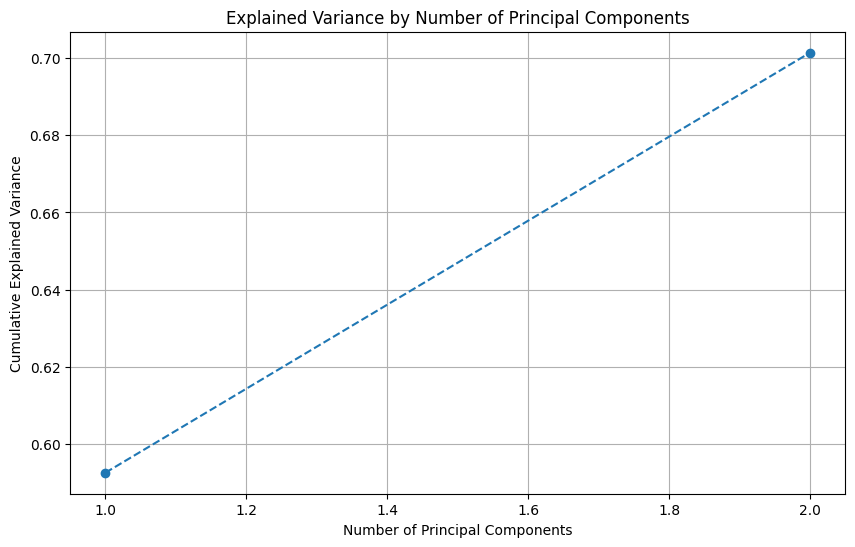

In [29]:
# Apply PCA to reduce dimensionality
pca = PCA(n_components=2) # Reduce to 2 principal components for visualization
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio by principal components: {pca.explained_variance_ratio_.sum():.2f}")

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])

# Display the first 5 rows of the PCA DataFrame
display(pca_df.head())

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Explained Variance by Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

## Customer Segmentation: K-Means Clustering

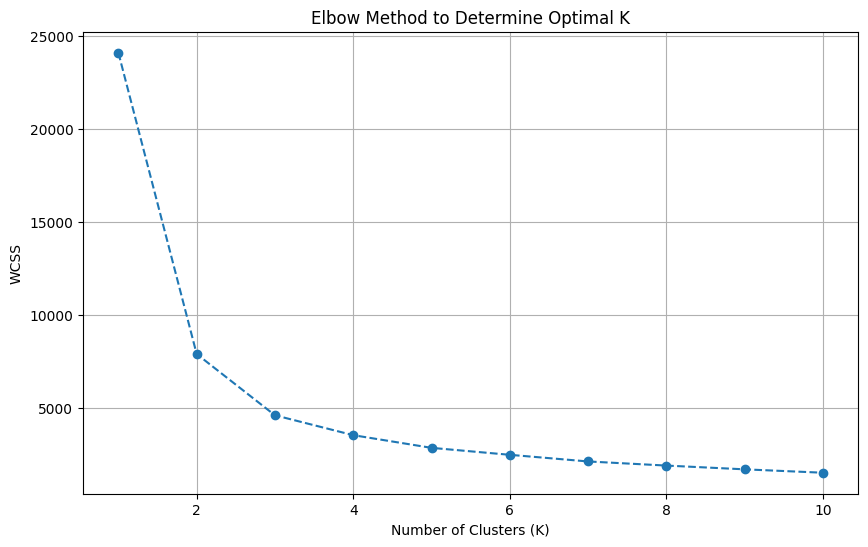

Elbow Method plot generated. Please analyze the plot to choose an optimal K.


In [30]:
from sklearn.cluster import KMeans

# Determine the optimal number of clusters using the Elbow Method
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

print("Elbow Method plot generated. Please analyze the plot to choose an optimal K.")

Based on the Elbow Method plot, let's choose a suitable number of clusters (e.g., K=4 or K=5) for the K-Means algorithm. We will proceed with K=4 for demonstration purposes. You can modify this value if your interpretation of the elbow plot suggests a different optimal number of clusters.

In [31]:
# Apply K-Means clustering with the chosen number of clusters
# Let's assume the optimal K is 4 based on the elbow plot analysis
optimal_k = 4 # This can be changed based on the elbow plot interpretation
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# Add the cluster labels to the PCA DataFrame
pca_df['Cluster'] = clusters

# Add the cluster labels to the original DataFrame for further analysis
data['Cluster'] = clusters

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("Distribution of customers per cluster:")
display(data['Cluster'].value_counts())

# Display the head of the PCA DataFrame with cluster labels
display(pca_df.head())

K-Means clustering applied with 4 clusters.
Distribution of customers per cluster:


,count
Cluster,
0,863
2,389
1,389
3,380


,Principal_Component_1,Principal_Component_2,Cluster
0,4.993189,0.411334,2
1,-3.079882,-0.943130,0
2,1.824878,0.232295,1
3,-3.095408,-0.448724,0
4,-0.163483,1.004642,3


## Visualization of Customer Segments

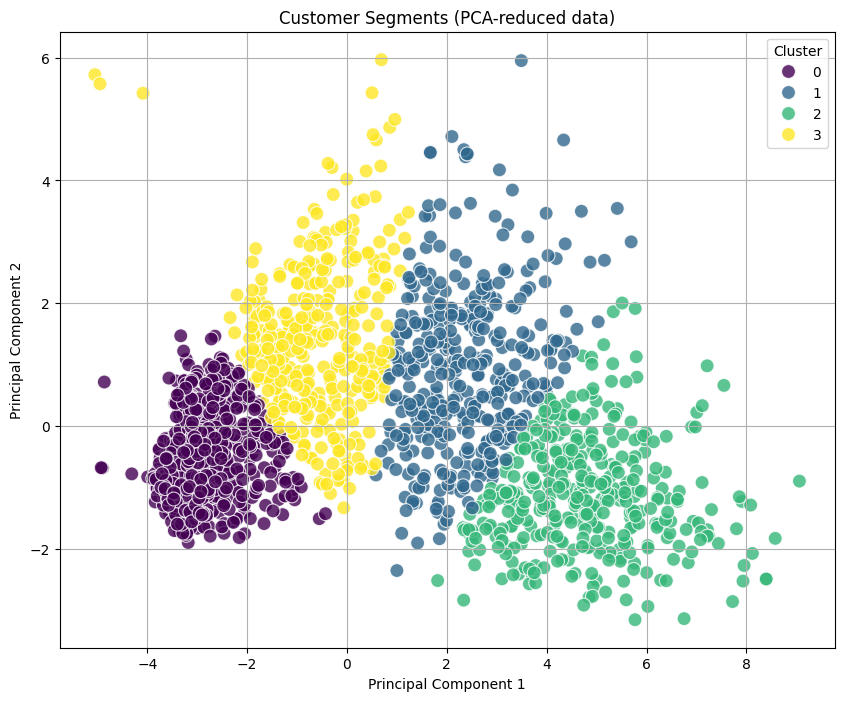

Cluster visualization generated. Please analyze the plot to understand the distinct groups.


In [32]:
# Visualize the clusters on the PCA-reduced data
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal_Component_1', y='Principal_Component_2', hue='Cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments (PCA-reduced data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print("Cluster visualization generated. Please analyze the plot to understand the distinct groups.")

## Insights and Recommendations: Cluster Profiling

In [33]:
# Analyze the characteristics of each cluster by looking at the mean values of the original features
cluster_profiles = data.groupby('Cluster')[features_for_clustering + ['Kidhome', 'Teenhome', 'Recency', 'Response']].mean()
display(cluster_profiles)

print("Cluster profiles generated. Analyze the mean values of features for each cluster to understand their unique characteristics.")

,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,...,NumWebVisitsMonth,MntTotal,MntRegularProds,Total_Spending,Total_Purchases,Avg_Purchase_Value,Kidhome,Teenhome,Recency,Response
Cluster,,,,,,,,,,,,,,,,,,,,,
0,33948.655852,33.877173,4.344148,18.865585,5.853998,4.650058,13.633835,1.857474,1.914253,0.476246,...,6.370800,67.590962,53.957126,81.224797,7.362688,10.267608,0.778679,0.460023,48.924681,0.091541
1,65754.429306,582.017995,40.874036,220.557841,53.205656,41.118252,73.964010,2.881748,6.462725,4.496144,...,4.776350,937.773779,863.809769,1011.737789,22.820051,45.965623,0.128535,0.704370,49.120823,0.146530
2,78202.475578,669.678663,73.138817,516.712082,108.822622,77.092545,76.717224,1.105398,4.964010,6.200514,...,2.616967,1445.444730,1368.727506,1522.161954,20.588689,76.623153,0.020566,0.138817,49.465296,0.318766
3,50429.010526,271.776316,13.639474,85.600000,20.831579,13.455263,48.381579,4.092105,5.842105,2.034211,...,6.365789,405.302632,356.921053,453.684211,18.073684,24.954234,0.436842,0.802632,47.936842,0.134211


Cluster profiles generated. Analyze the mean values of features for each cluster to understand their unique characteristics.


Based on the cluster profiles, we can now provide insights and recommendations for each segment.